# Analyse exploratoire (EDA) : House Prices

## Objectif
Explorer les relations entre les variables explicatives et le prix de vente, identifier les variables les plus corrélées à la cible, et comprendre la structure des données avant modélisation.

## Étapes
1. Chargement du dataset nettoyé
2. Statistiques descriptives générales
3. Matrice de corrélation avec la variable cible
4. Analyse des variables numériques les plus corrélées
5. Analyse des variables catégorielles importantes
6. Synthèse des variables à retenir pour la modélisation

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/train_cleaned.csv', keep_default_na=False, na_values=[''])
print(df.shape)
df.head()

(1458, 82)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SalePrice_log
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,...,None,None,None,0,2,2008,WD,Normal,208500,12.247699
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,...,None,None,None,0,5,2007,WD,Normal,181500,12.109016
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,...,None,None,None,0,9,2008,WD,Normal,223500,12.317171
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,...,None,None,None,0,2,2006,WD,Abnorml,140000,11.849405
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,...,None,None,None,0,12,2008,WD,Normal,250000,12.429220


In [26]:
cols_categorical = ['MSSubClass', 'YrSold', 'MoSold']
df[cols_categorical] = df[cols_categorical].astype(str)

df.describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,SalePrice,SalePrice_log
count,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,...,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,730.251715,69.992112,10459.936900,6.093964,5.576132,1971.218107,1984.834019,102.189986,438.827160,46.613169,...,472.050069,94.084362,46.245542,21.984225,3.414266,15.081619,2.433471,43.548697,180932.919067,12.024015
std,421.601532,21.469099,9859.198156,1.376369,1.113359,30.193754,20.641760,179.109864,432.969094,161.420729,...,212.239248,125.350021,65.312932,61.155666,29.337173,55.792877,38.209947,496.460799,79495.055285,0.399713
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34900.000000,10.460271
25%,365.250000,60.000000,7544.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,...,331.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,129925.000000,11.774720
50%,730.500000,70.000000,9475.000000,6.000000,5.000000,1972.500000,1994.000000,0.000000,382.000000,0.000000,...,479.500000,0.000000,24.500000,0.000000,0.000000,0.000000,0.000000,0.000000,163000.000000,12.001512
75%,1094.750000,80.000000,11600.000000,7.000000,6.000000,2000.000000,2004.000000,163.750000,711.000000,0.000000,...,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,214000.000000,12.273736
max,1460.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,2188.000000,1474.000000,...,1390.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,755000.000000,13.534474


In [27]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr()['SalePrice_log'].sort_values(ascending=False)
correlations

SalePrice_log    1.000000
SalePrice        0.948396
OverallQual      0.821405
GrLivArea        0.725211
GarageCars       0.681033
GarageArea       0.656129
TotalBsmtSF      0.647563
1stFlrSF         0.620500
FullBath         0.595899
YearBuilt        0.587043
YearRemodAdd     0.565992
TotRmsAbvGrd     0.537702
Fireplaces       0.491998
MasVnrArea       0.430570
BsmtFinSF1       0.392283
LotFrontage      0.369701
GarageYrBlt      0.349013
WoodDeckSF       0.334251
OpenPorchSF      0.325215
2ndFlrSF         0.319953
HalfBath         0.314186
LotArea          0.260544
BsmtFullBath     0.237099
BsmtUnfSF        0.221892
BedroomAbvGr     0.209035
ScreenPorch      0.121245
PoolArea         0.074338
3SsnPorch        0.054914
BsmtFinSF2       0.004863
BsmtHalfBath    -0.005124
Id              -0.017774
MiscVal         -0.020012
OverallCond     -0.036821
LowQualFinSF    -0.037951
KitchenAbvGr    -0.147534
EnclosedPorch   -0.149029
Name: SalePrice_log, dtype: float64

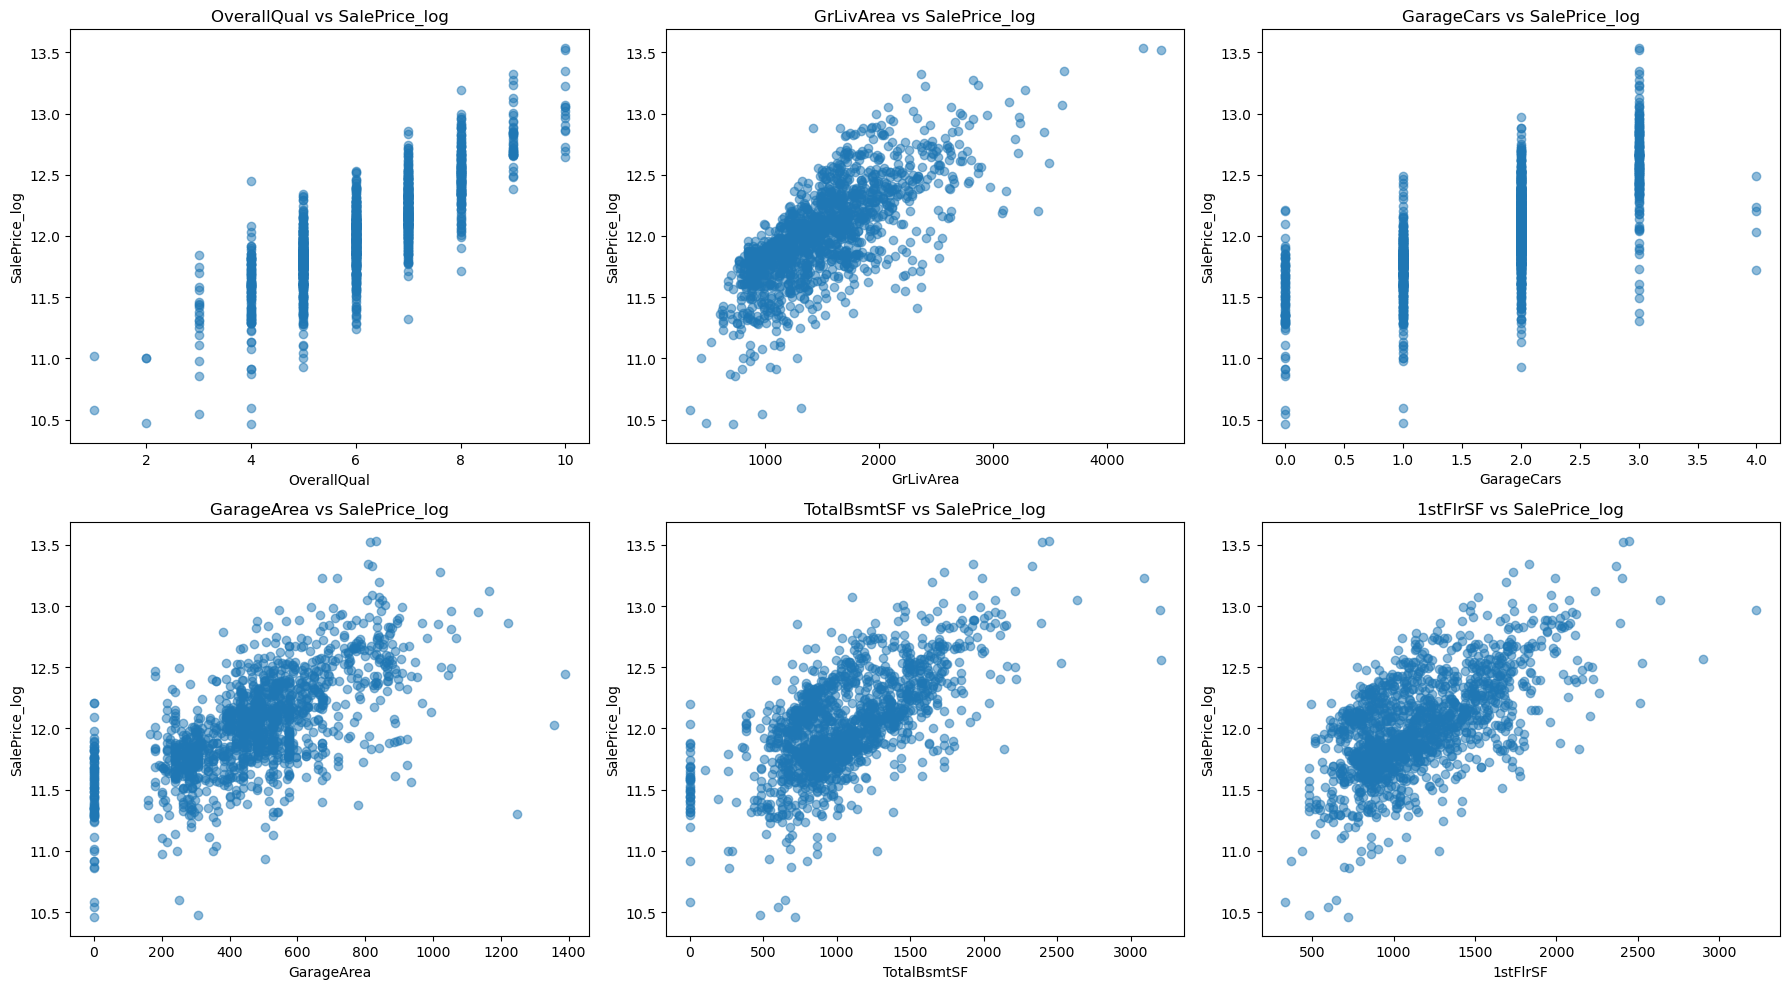

In [28]:
top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df['SalePrice_log'], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice_log')
    axes[i].set_title(f'{col} vs SalePrice_log')
plt.tight_layout()
plt.show()

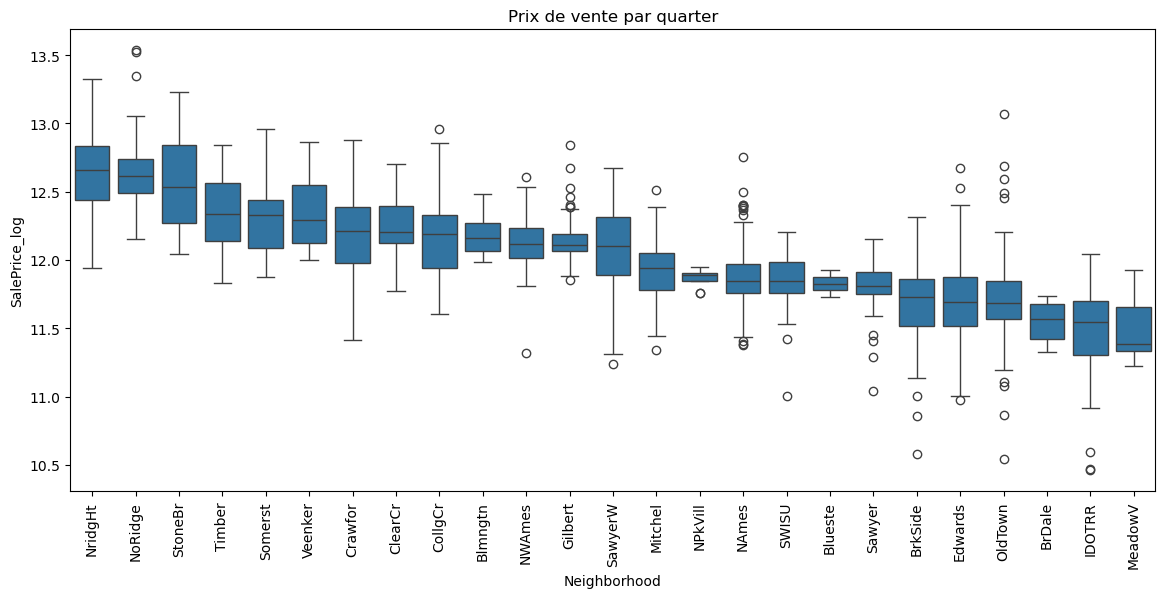

In [29]:
plt.figure(figsize=(14, 6))
order = df.groupby('Neighborhood')['SalePrice_log'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice_log', order=order)
plt.xticks(rotation=90)
plt.title('Prix de vente par quarter')
plt.show()

In [30]:
df['ExterQual'].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

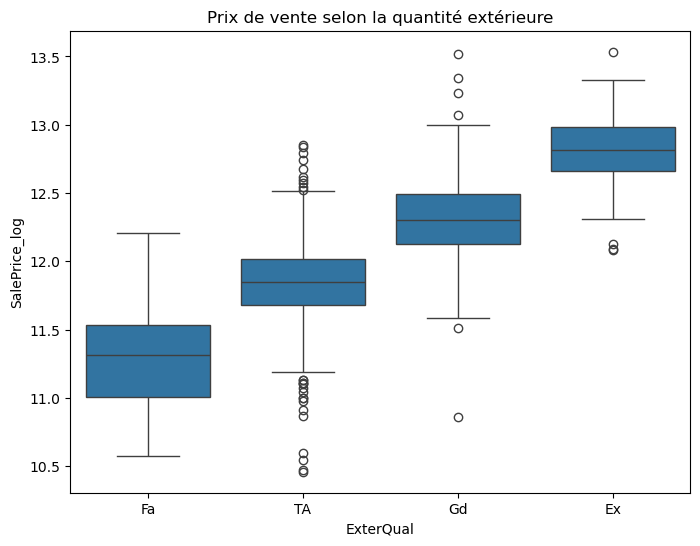

In [31]:
plt.figure(figsize=(8, 6))
order = ['Fa', 'TA', 'Gd', 'Ex']
sns.boxplot(data=df, x='ExterQual', y='SalePrice_log', order=order)
plt.title('Prix de vente selon la quantité extérieure')
plt.show()

In [32]:
df.groupby('ExterQual')['SalePrice_log'].median()

ExterQual
Ex    12.818776
Fa    11.317526
Gd    12.301387
TA    11.845468
Name: SalePrice_log, dtype: float64

In [33]:
df.select_dtypes(include='object').columns

Index(['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'MoSold', 'YrSold', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [34]:
print(df['KitchenQual'].unique())

['Gd' 'TA' 'Ex' 'Fa']


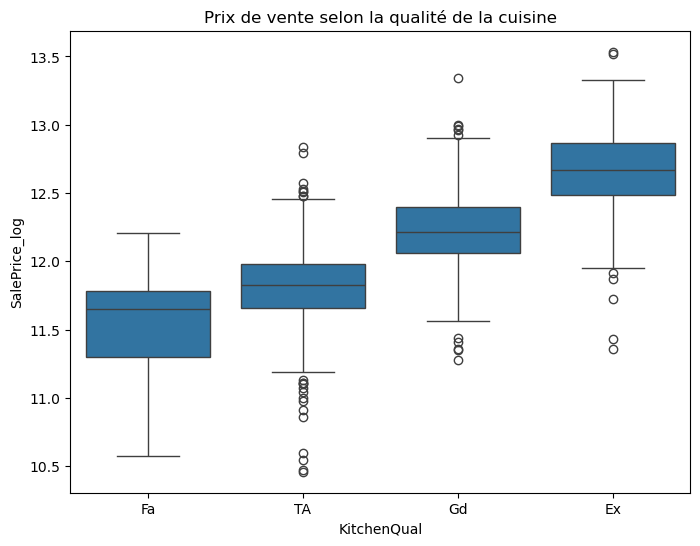

In [35]:
order = sorted(df['KitchenQual'].unique(), key=lambda x: ['Fa', 'TA', 'Gd', 'Ex'].index(x))
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='KitchenQual', y='SalePrice_log', order=order)
plt.title('Prix de vente selon la qualité de la cuisine')
plt.show()

In [36]:
df.groupby('KitchenQual')['SalePrice_log'].median()

KitchenQual
Ex    12.669906
Fa    11.652696
Gd    12.213051
TA    11.827744
Name: SalePrice_log, dtype: float64

In [37]:
qual_cols = ['BsmtQual', 'GarageQual', 'FireplaceQu', 'HeatingQC', 'PoolQC']

for col in qual_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print(df.groupby(col)['SalePrice_log'].median().sort_values())
    print()

--- BsmtQual ---
['Gd' 'TA' 'Ex' 'None' 'Fa']
BsmtQual
None    11.530775
Fa      11.626263
TA      11.816734
Gd      12.165620
Ex      12.669810
Name: SalePrice_log, dtype: float64

--- GarageQual ---
['TA' 'Fa' 'Gd' 'None' 'Ex' 'Po']
GarageQual
Po      11.477309
None    11.512935
Fa      11.652696
Ex      11.755879
TA      12.043560
Gd      12.243951
Name: SalePrice_log, dtype: float64

--- FireplaceQu ---
['None' 'TA' 'Gd' 'Fa' 'Ex' 'Po']
FireplaceQu
Po      11.786589
None    11.813037
Fa      11.970357
TA      12.141539
Gd      12.240479
Ex      12.657939
Name: SalePrice_log, dtype: float64

--- HeatingQC ---
['Ex' 'Gd' 'TA' 'Fa' 'Po']
HeatingQC
Po    11.373675
Fa    11.724005
TA    11.813037
Gd    11.931642
Ex    12.180760
Name: SalePrice_log, dtype: float64

--- PoolQC ---
['None' 'Ex' 'Fa' 'Gd']
PoolQC
None    12.000898
Fa      12.267739
Gd      12.286923
Ex      12.944243
Name: SalePrice_log, dtype: float64



## Synthèse de l'EDA

### Variables numériques les plus corrélées à SalePrice_log
- OverallQual (0.82)
- GrLivArea (0.73)
- GarageCars (0.68)
- GarageArea (0.66)
- TotalBsmtSF (0.65)
- 1stFlrSF (0.62)

### Variables catégorielles à fort impact
- Neighborhood : écart de prix x3 entre quartiers, encodage one-hot nécessaire
- Variables de qualité (ExterQual, KitchenQual, BsmtQual, GarageQual, FireplaceQu, HeatingQC, PoolQC) : toutes ordinales, encodage numérique ordonné (None=0, Po=1, Fa=2, TA=3, Gd=4, Ex=5)

### Points de vigilance pour la modélisation
- Multicolinéarité probable entre GarageCars/GarageArea et TotalBsmtSF/1stFlrSF
- Variables avec beaucoup de zéros (GarageArea, TotalBsmtSF) créent une distribution bimodale
- OverallCond quasi non corrélée au prix, à surveiller